In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# Setup Spark (jika belum ada)
spark = SparkSession.builder \
    .appName("SimpleAggregationAnalysis") \
    .config("spark.driver.memory", "12g") \
    .getOrCreate()

KeyboardInterrupt: 

In [ ]:
# Load Members
members_table_path = "data/processed_eda/train_members_grouped.parquet"

print(f"Memuat data dari {members_table_path}...")
members_df = spark.read.parquet(members_table_path)
members_df.cache()
members_df.printSchema()

Memuat data dari data/processed_eda/train_members_grouped.parquet...
root
 |-- msno: string (nullable = true)
 |-- is_churn: integer (nullable = true)
 |-- city: integer (nullable = true)
 |-- bd: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- registered_via: integer (nullable = true)
 |-- registration_init_time: integer (nullable = true)
 |-- bd_clean: string (nullable = true)
 |-- bd_int: integer (nullable = true)
 |-- age_group: string (nullable = true)



In [3]:
# Load Members
transactions_table_path = "data/processed_eda/full_analysis_transactions.parquet"

print(f"Memuat data dari {transactions_table_path}...")
transactions_df = spark.read.parquet(transactions_table_path)
transactions_df.cache()
transactions_df.printSchema()

Memuat data dari data/processed_eda/full_analysis_transactions.parquet...
root
 |-- msno: string (nullable = true)
 |-- payment_method_id: integer (nullable = true)
 |-- payment_plan_days: integer (nullable = true)
 |-- plan_list_price: integer (nullable = true)
 |-- actual_amount_paid: integer (nullable = true)
 |-- is_auto_renew: integer (nullable = true)
 |-- transaction_date: integer (nullable = true)
 |-- membership_expire_date: integer (nullable = true)
 |-- is_cancel: integer (nullable = true)
 |-- is_churn: integer (nullable = true)
 |-- city: integer (nullable = true)
 |-- bd: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- registered_via: integer (nullable = true)
 |-- registration_init_time: integer (nullable = true)
 |-- bd_clean: string (nullable = true)
 |-- bd_int: integer (nullable = true)
 |-- age_group: string (nullable = true)



In [4]:
# Load Members
logs_table_path = "data/processed_eda/plot_data_logs.parquet"

print(f"Memuat data dari {logs_table_path}...")
logs_df = spark.read.parquet(logs_table_path)
logs_df.cache()
logs_df.printSchema()

Memuat data dari data/processed_eda/plot_data_logs.parquet...
root
 |-- msno: string (nullable = true)
 |-- is_churn: integer (nullable = true)
 |-- city: integer (nullable = true)
 |-- bd: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- registered_via: integer (nullable = true)
 |-- registration_init_time: integer (nullable = true)
 |-- bd_clean: string (nullable = true)
 |-- bd_int: integer (nullable = true)
 |-- age_group: string (nullable = true)
 |-- total_secs_sum: double (nullable = true)
 |-- total_active_days: long (nullable = true)
 |-- total_songs_100: long (nullable = true)
 |-- total_songs_all: long (nullable = true)
 |-- completion_rate: double (nullable = true)
 |-- listening_time_group: string (nullable = true)
 |-- active_days_group: string (nullable = true)
 |-- completion_habit: string (nullable = true)



In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pyspark.sql import functions as F

def plot_churn_impact(df, col_name, title):
    """
    Visualisasi untuk menampilkan secara langsung jumlah user yang churn.
    """
    
    # 1. Agregasi Data
    stats_df = df.withColumn(col_name, F.col(col_name).cast("string")) \
        .fillna('Unknown', subset=[col_name]) \
        .groupBy(col_name) \
        .agg(
            F.avg("is_churn").alias("churn_rate"),
            F.count("msno").alias("total_users")
        )
    
    # Hitung jumlah orang churn
    stats_df = stats_df.withColumn("total_churned_users", F.col("total_users") * F.col("churn_rate"))
    
    # Filter noise
    stats_df = stats_df.filter(F.col("total_users") > 50)
    
    # Sort dari yang paling banyak churn
    stats_df = stats_df.orderBy(F.desc("total_churned_users"))

    # Konversi ke Pandas
    pdf = stats_df.toPandas()

    # 2. Plotting Bar Chart Tunggal
    plt.figure(figsize=(14, 7))
    
    # Plot Batang Merah
    ax = sns.barplot(data=pdf, x=col_name, y='total_churned_users', color='#c44e52')
    
    # Label di atas batang
    for index, row in pdf.iterrows():
        # Format angka (ribuan)
        val = row['total_churned_users']
        label_num = f"{int(val/1000)}k" if val > 1000 else str(int(val))
        
        # Tambahkan detail persen juga biar lengkap (opsional)
        label_full = f"{label_num}\n({row['churn_rate']:.1%})"
        
        ax.text(index, val, label_full, color='black', ha="center", va="bottom", fontweight='bold')

    plt.title(f"{title}\n(Diurutkan berdasarkan Jumlah User yang Churn)", fontsize=16, pad=20)
    plt.xlabel(col_name, fontsize=12)
    plt.ylabel('Total User Churn (Orang)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

--- 1. ANALISIS DEMOGRAFI ---


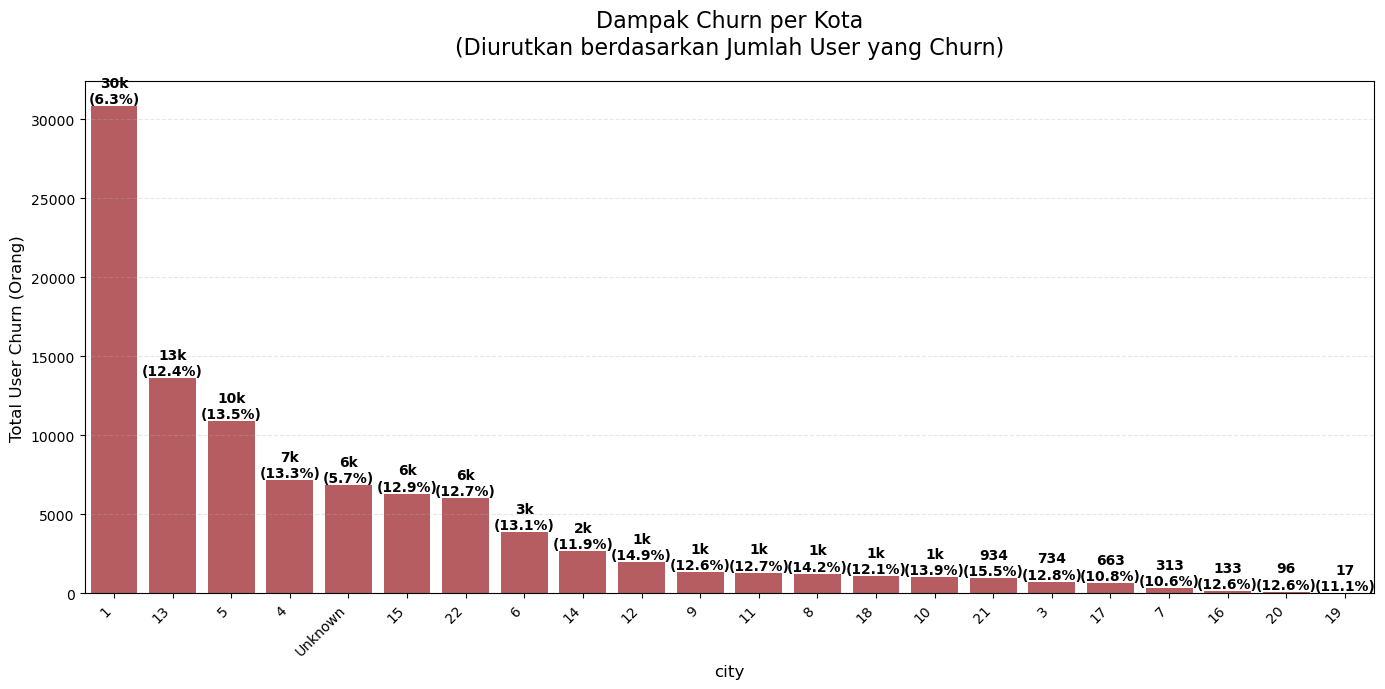

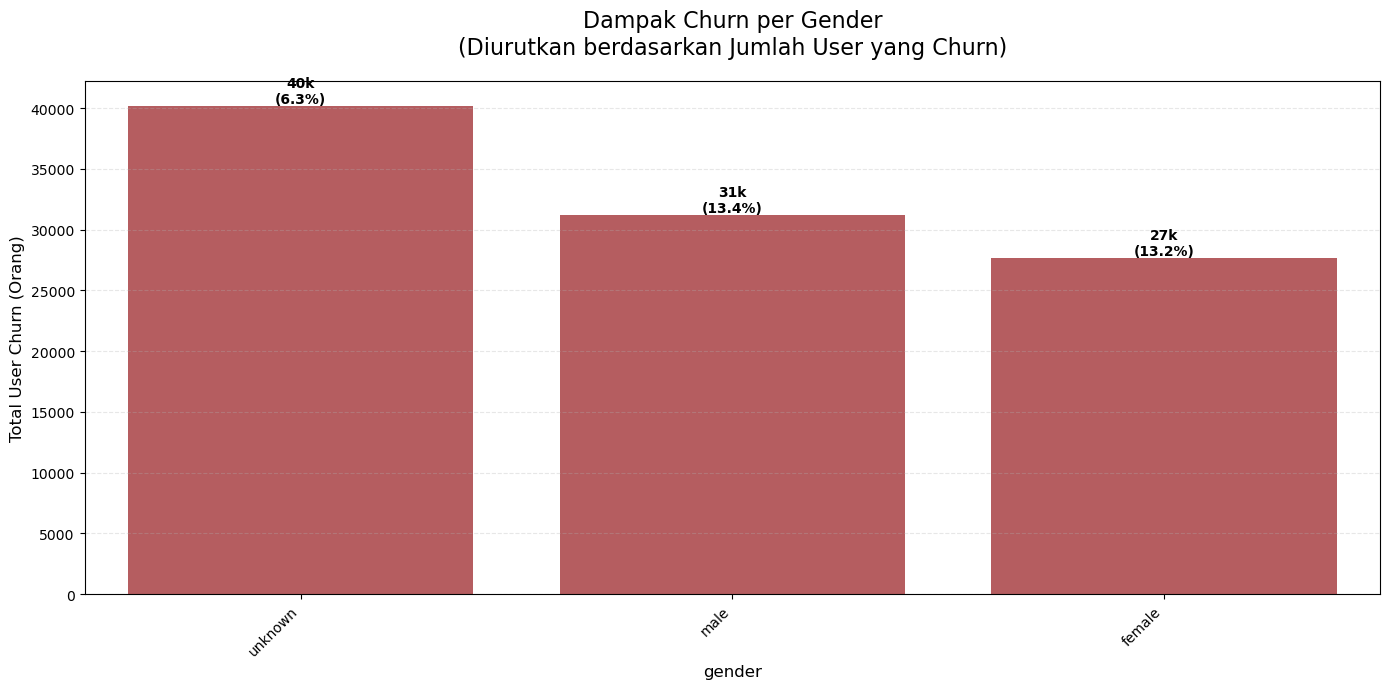

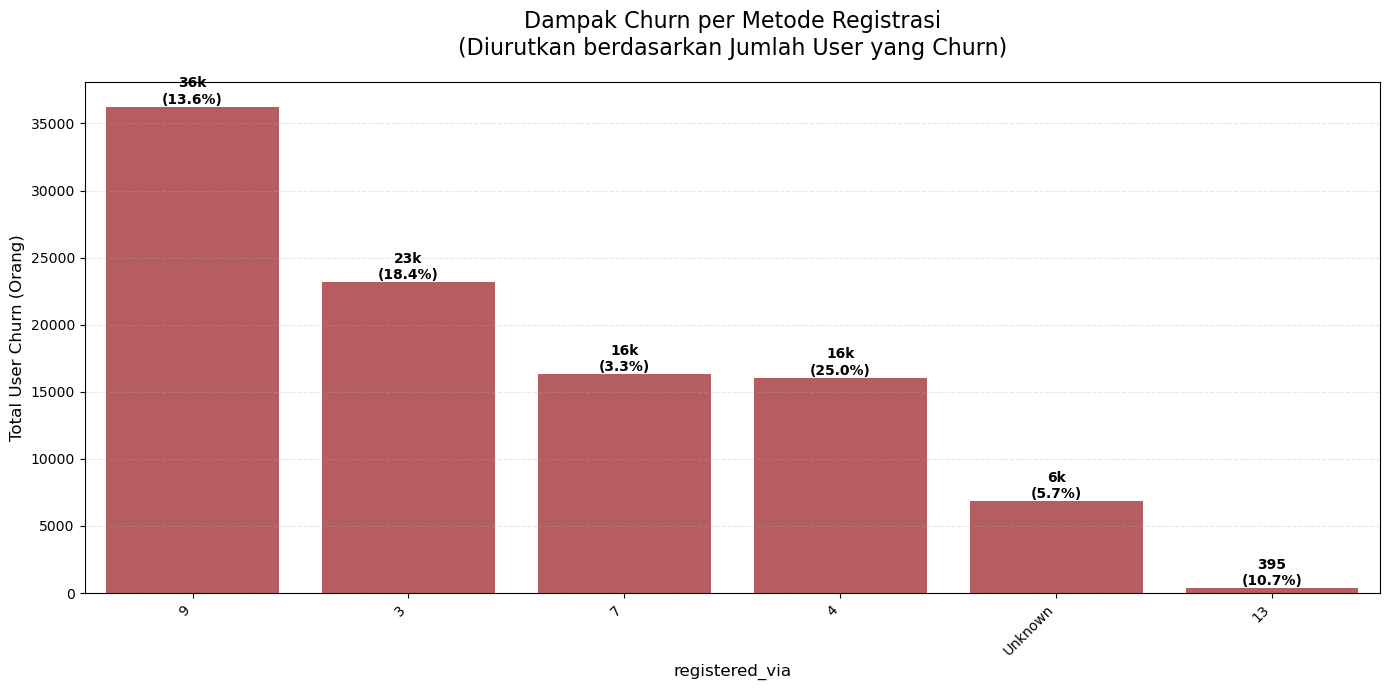

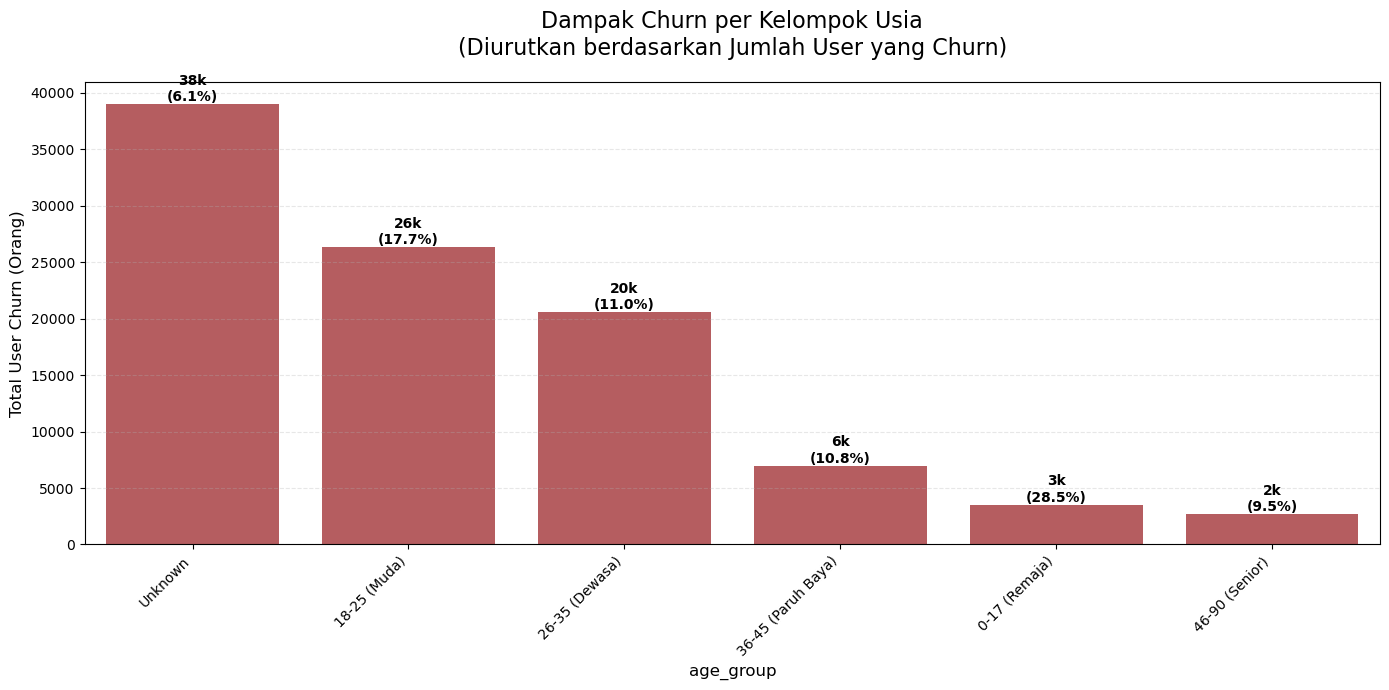

In [23]:
# Pastikan members_df sudah diload sebelumnya
print("--- 1. ANALISIS DEMOGRAFI ---")

# A. Analisis Kota
# Kita sort by 'impact' untuk melihat kota mana penyumbang churn terbanyak (bukan cuma persentase)
plot_churn_impact(members_df, "city", "Dampak Churn per Kota")

# B. Analisis Gender
plot_churn_impact(members_df, "gender", "Dampak Churn per Gender")

# C. Analisis Metode Registrasi
plot_churn_impact(members_df, "registered_via", "Dampak Churn per Metode Registrasi")

# D. Analisis Age Group
plot_churn_impact(members_df, "age_group", "Dampak Churn per Kelompok Usia")

Sedang memproses data transaksi...
--- ANALISIS TRANSAKSI: SUMBER CHURN TERBESAR (ORANG) ---


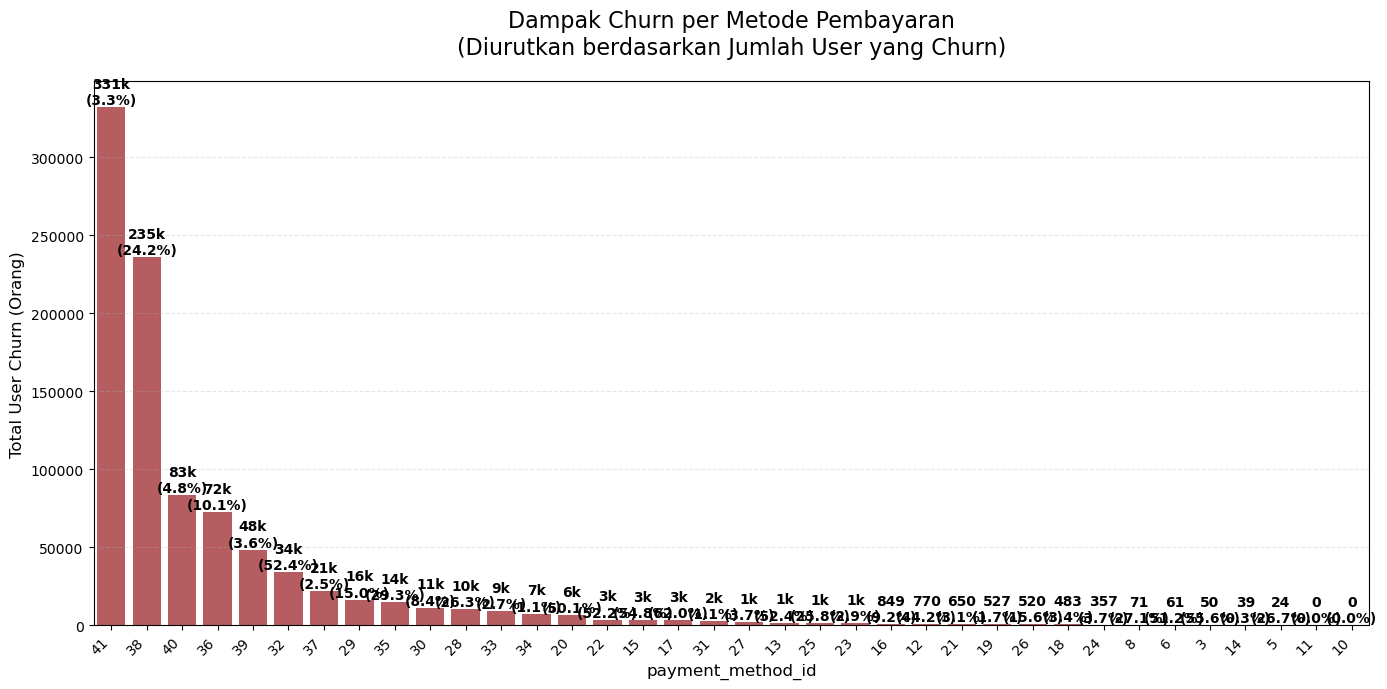

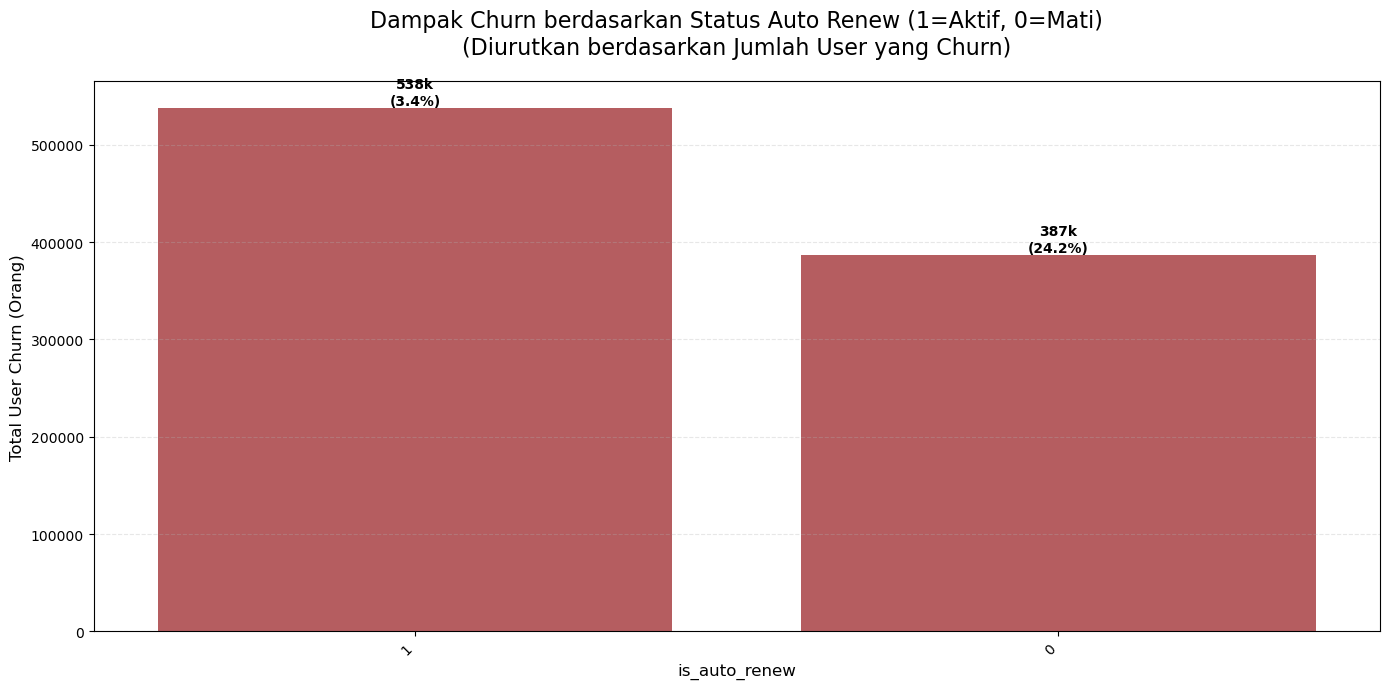

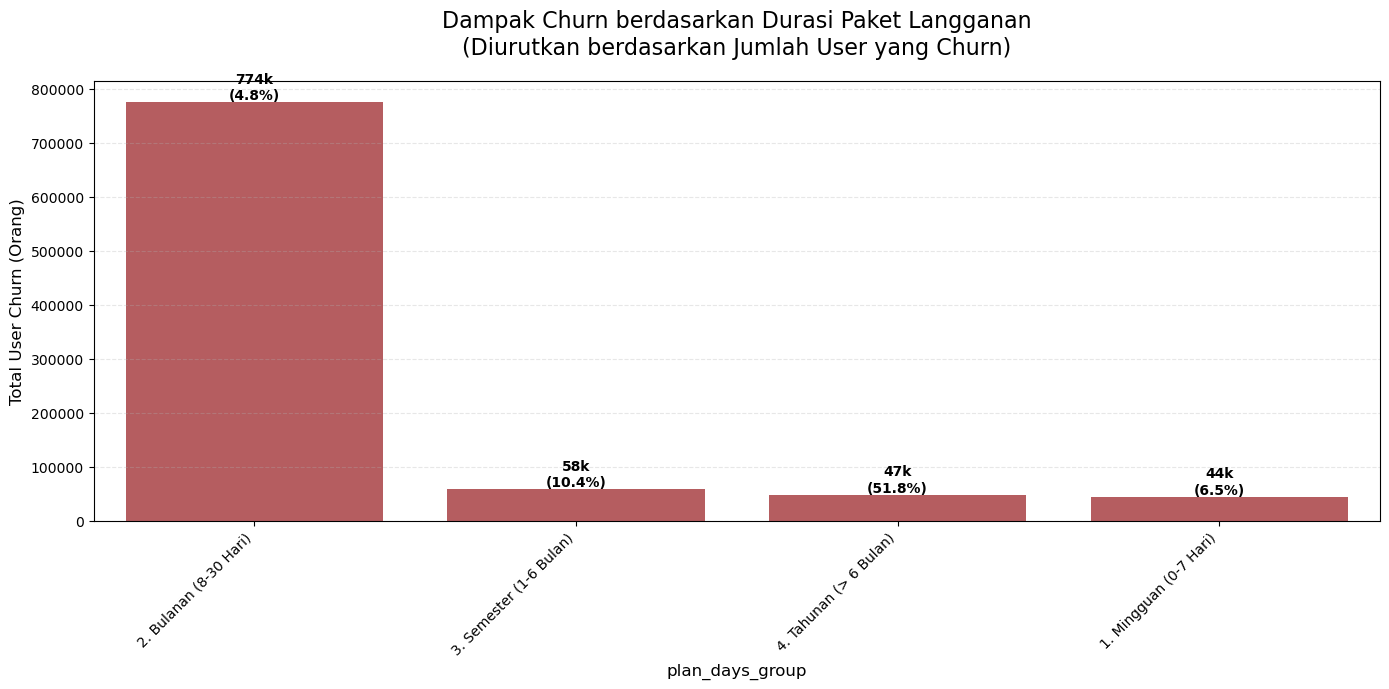

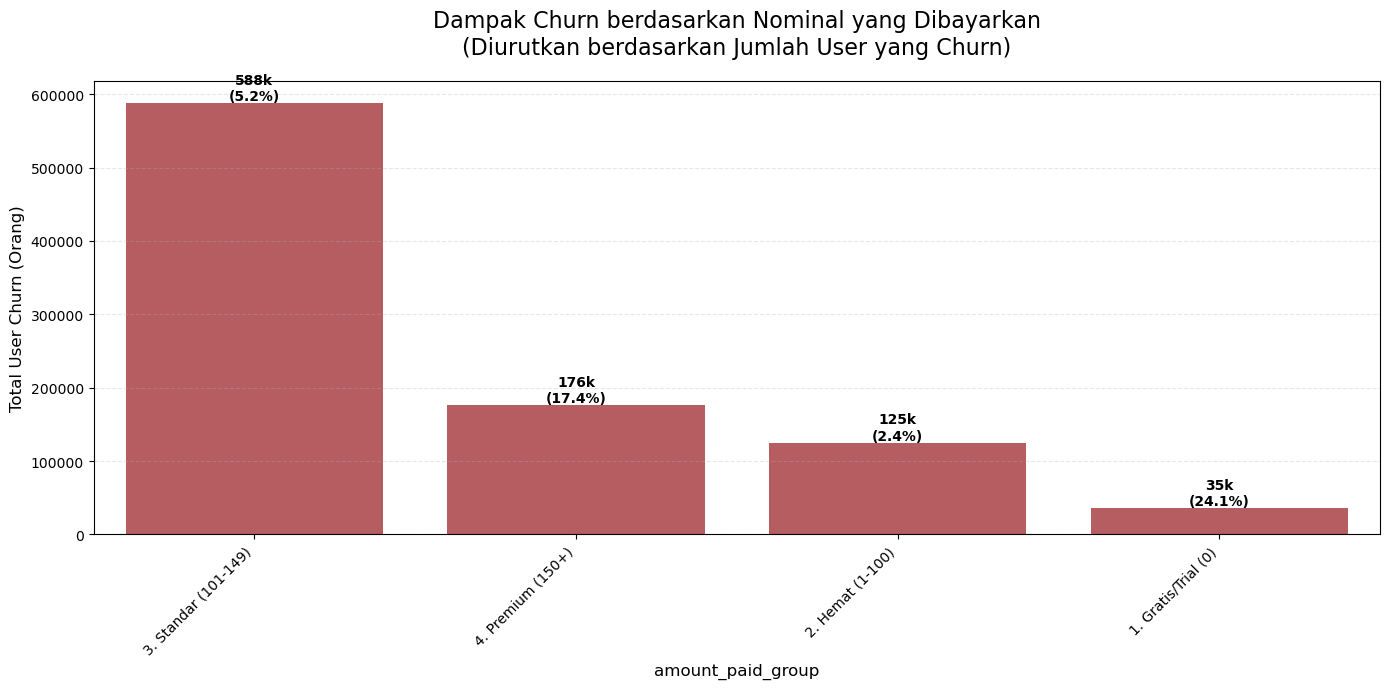

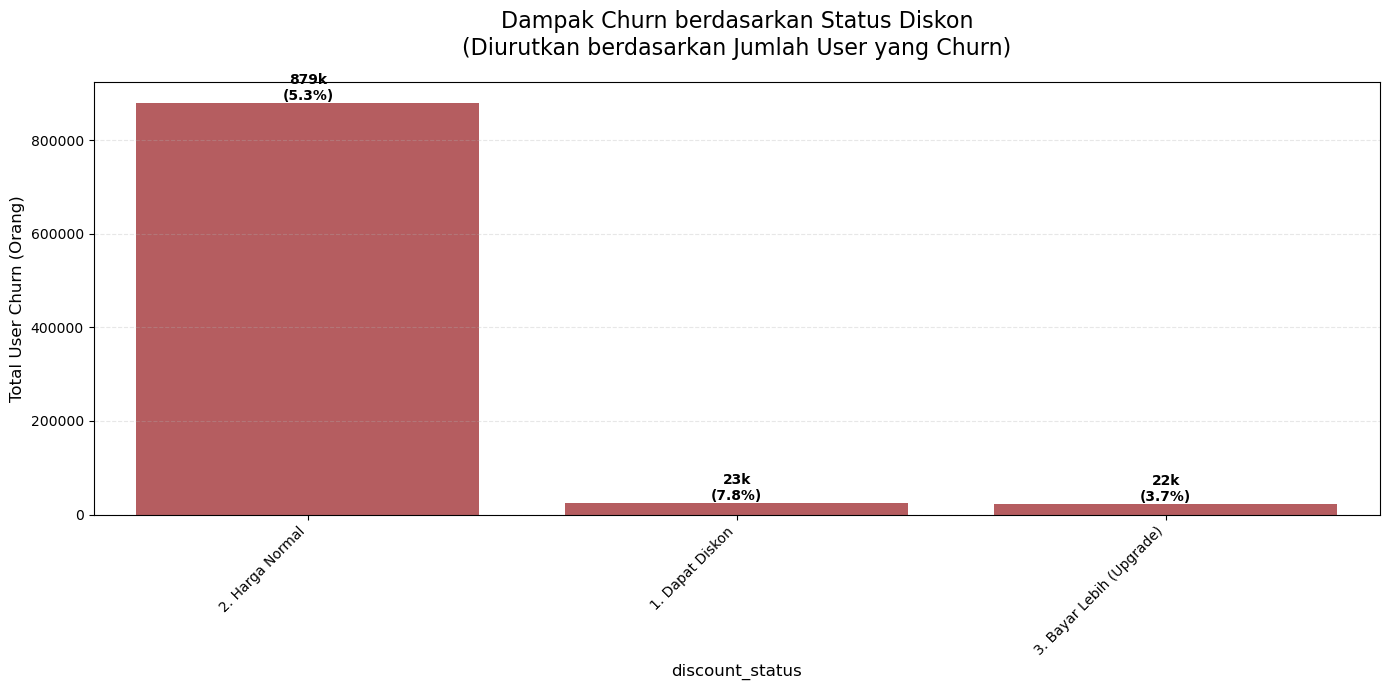

In [24]:
# --- 1. PERSIAPAN DATA TRANSAKSI (BINNING) ---
print("Sedang memproses data transaksi...")

# Filter data yang valid (memiliki label churn)
plot_data_trans = transactions_df.filter(F.col("is_churn").isNotNull())

# Pengelompokan (Binning) agar data numerik bisa dibuat kategori
plot_data_trans_binned = plot_data_trans.withColumn(
    "plan_days_group",
    F.when(F.col("payment_plan_days") <= 7, "1. Mingguan (0-7 Hari)")
     .when((F.col("payment_plan_days") > 7) & (F.col("payment_plan_days") <= 30), "2. Bulanan (8-30 Hari)")
     .when((F.col("payment_plan_days") > 30) & (F.col("payment_plan_days") <= 180), "3. Semester (1-6 Bulan)")
     .otherwise("4. Tahunan (> 6 Bulan)")
).withColumn(
    "amount_paid_group",
    F.when(F.col("actual_amount_paid") == 0, "1. Gratis/Trial (0)")
     .when((F.col("actual_amount_paid") > 0) & (F.col("actual_amount_paid") <= 100), "2. Hemat (1-100)")
     .when((F.col("actual_amount_paid") > 100) & (F.col("actual_amount_paid") <= 149), "3. Standar (101-149)")
     .otherwise("4. Premium (150+)")
).withColumn(
    "discount_status",
    F.when(F.col("actual_amount_paid") < F.col("plan_list_price"), "1. Dapat Diskon")
     .when(F.col("actual_amount_paid") == F.col("plan_list_price"), "2. Harga Normal")
     .when(F.col("actual_amount_paid") > F.col("plan_list_price"), "3. Bayar Lebih (Upgrade)")
     .otherwise("4. Lainnya")
)

# --- 2. EKSEKUSI VISUALISASI (ABSOLUTE IMPACT) ---

print("--- ANALISIS TRANSAKSI: SUMBER CHURN TERBESAR (ORANG) ---")

# A. Metode Pembayaran
# Melihat channel pembayaran mana yang paling banyak kehilangan user
plot_churn_impact(
    plot_data_trans_binned, 
    "payment_method_id", 
    "Dampak Churn per Metode Pembayaran"
)

# B. Status Auto Renew
# Melihat berapa banyak orang yang churn dari kelompok Auto-Renew vs Manual
plot_churn_impact(
    plot_data_trans_binned, 
    "is_auto_renew", 
    "Dampak Churn berdasarkan Status Auto Renew (1=Aktif, 0=Mati)"
)

# C. Durasi Paket (Plan Days)
# Melihat paket durasi apa yang paling banyak ditinggalkan user
plot_churn_impact(
    plot_data_trans_binned, 
    "plan_days_group", 
    "Dampak Churn berdasarkan Durasi Paket Langganan"
)

# D. Kelompok Harga Bayar (Amount Paid)
# Melihat segmen harga mana yang paling banyak churn
plot_churn_impact(
    plot_data_trans_binned, 
    "amount_paid_group", 
    "Dampak Churn berdasarkan Nominal yang Dibayarkan"
)

# E. Status Diskon
# Melihat apakah diskon benar-benar menyelamatkan banyak user atau tidak
plot_churn_impact(
    plot_data_trans_binned, 
    "discount_status", 
    "Dampak Churn berdasarkan Status Diskon"
)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pyspark.sql import functions as F

# --- FUNGSI PLOTTING GENERAL (Churn Rate by Category) ---
def plot_churn_by_category(df, col_name, title, sort_by_risk=True, x_label=None):
    """
    Fungsi untuk membuat Stacked Bar Chart General:
    Memvisualisasikan distribusi Churn vs Retained berdasarkan kategori tertentu.
    """
    # 1. Hitung Statistik di Spark
    # Cast ke string agar data numerik (seperti ID) dianggap kategori
    stats_df = df.withColumn(col_name, F.col(col_name).cast("string")) \
        .fillna('Unknown', subset=[col_name]) \
        .groupBy(col_name) \
        .agg(
            F.avg("is_churn").alias("churn_rate"),
            F.count("msno").alias("total_users")
        )
    
    # Filter kategori dengan jumlah user terlalu sedikit (< 50) agar plot rapi
    stats_df = stats_df.filter(F.col("total_users") > 50)

    # Urutkan berdasarkan Churn Rate tertinggi (opsional) atau berdasarkan nama
    if sort_by_risk:
        stats_df = stats_df.orderBy(F.desc("churn_rate"))
    else:
        stats_df = stats_df.orderBy(col_name)
    
    # 2. Konversi ke Pandas
    pdf = stats_df.toPandas()
    
    # Hitung Retention Rate (1 - Churn Rate)
    pdf['retention_rate'] = 1 - pdf['churn_rate']

    # 3. Plotting
    plt.figure(figsize=(14, 6))
    
    # Bar Retention (Bawah - Biru)
    p1 = plt.bar(pdf[col_name], pdf['retention_rate'], label='Retained (Tidak Churn)', color='#4c72b0')
    
    # Bar Churn (Atas - Merah)
    p2 = plt.bar(pdf[col_name], pdf['churn_rate'], bottom=pdf['retention_rate'], label='Churned', color='#c44e52')
    
    # Tambahkan label data
    for i, row in pdf.iterrows():
        # Label Persentase Churn (jika cukup besar)
        if row['churn_rate'] > 0.02: 
            plt.text(i, row['retention_rate'] + row['churn_rate']/2, 
                     f"{row['churn_rate']:.1%}", 
                     ha='center', va='center', color='white', fontweight='bold', fontsize=10)
        
        # Label Jumlah User (n=...)
        count_label = f"n={row['total_users']/1000:.0f}k" if row['total_users'] > 1000 else f"n={row['total_users']}"
        plt.text(i, 1.02, count_label, ha='center', fontsize=9, color='gray')

    # Kosmetik Plot
    final_xlabel = x_label if x_label else col_name
    plt.title(title, fontsize=16)
    plt.xlabel(final_xlabel, fontsize=12)
    plt.ylabel('Proporsi User', fontsize=12)
    plt.ylim(0, 1.1) # Memberi ruang untuk label n di atas
    plt.legend(loc='lower right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

print("Fungsi visualisasi siap digunakan.")

Fungsi visualisasi siap digunakan.


--- Analisis Demografis General ---


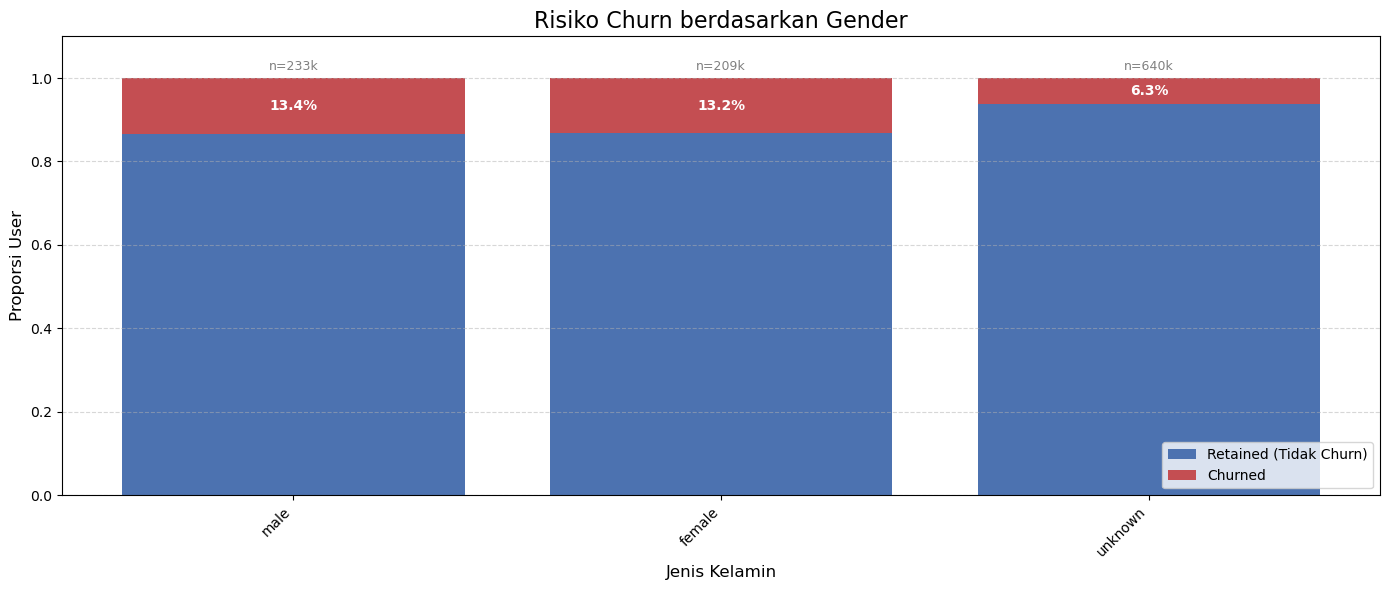

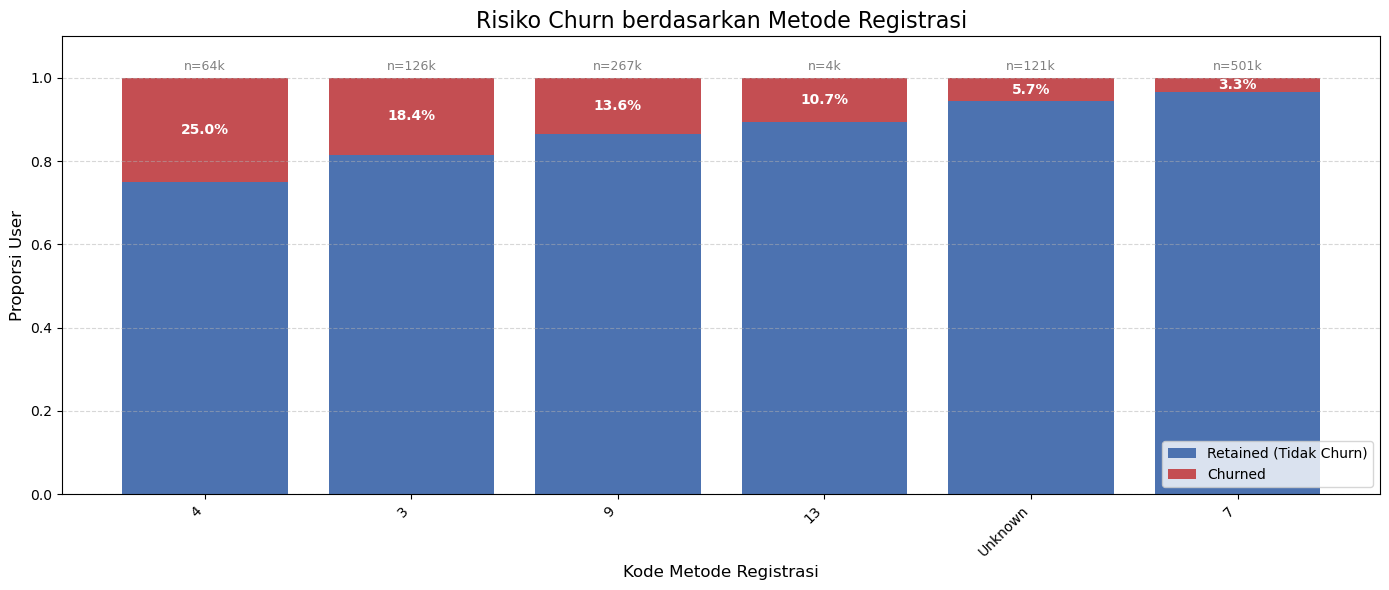

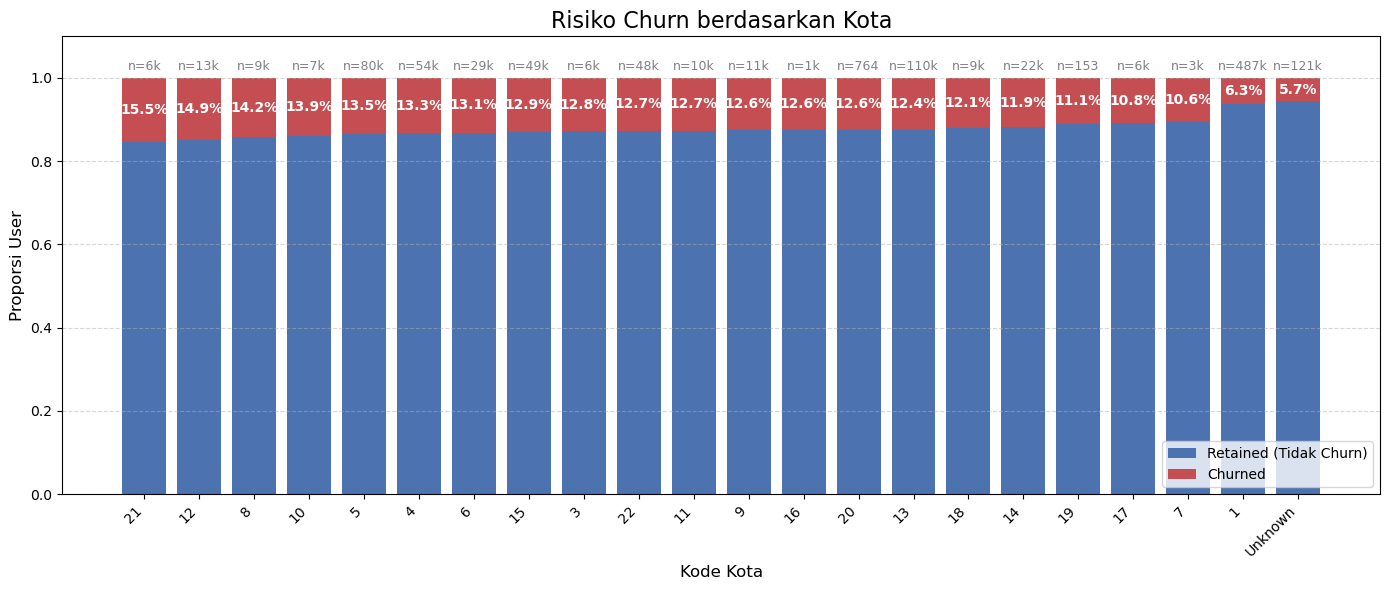

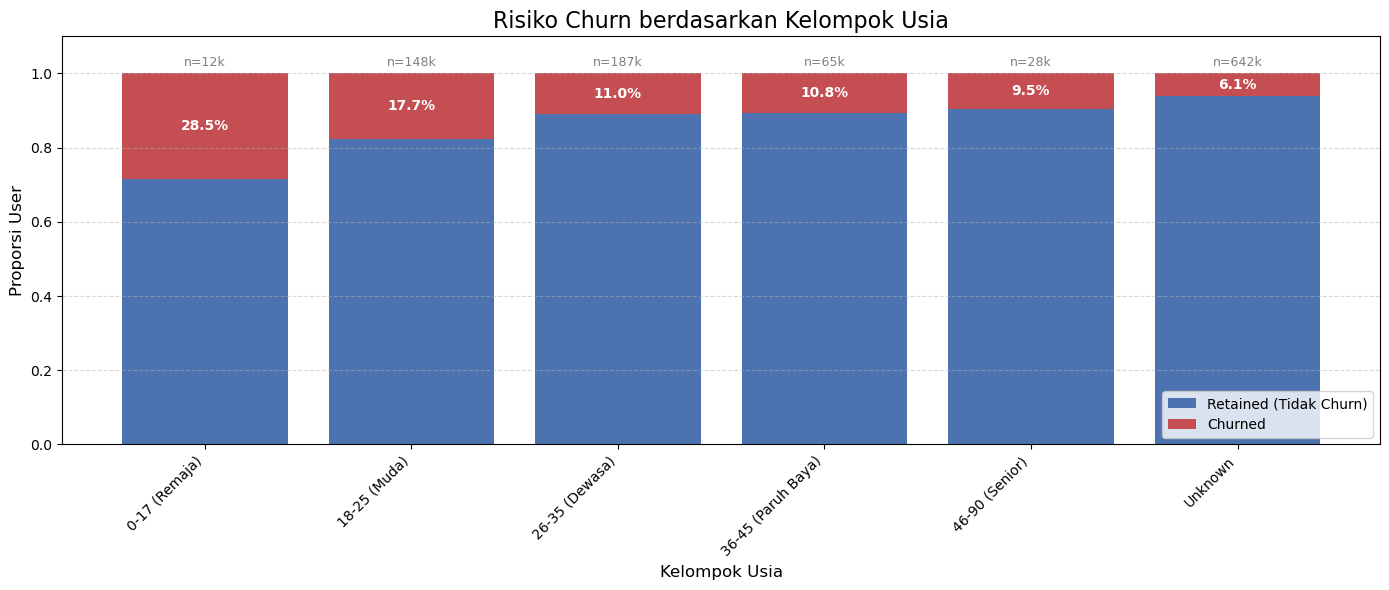

In [ ]:
print("--- Analisis Demografis General ---")

# 1. Plot Gender
plot_churn_by_category(
    members_df, 
    "gender", 
    "Risiko Churn berdasarkan Gender", 
    sort_by_risk=True,
    x_label="Jenis Kelamin"
)

# 2. Plot Registered Via
plot_churn_by_category(
    members_df, 
    "registered_via", 
    "Risiko Churn berdasarkan Metode Registrasi", 
    sort_by_risk=True,
    x_label="Kode Metode Registrasi"
)

# 3. Plot City
plot_churn_by_category(
    members_df, 
    "city", 
    "Risiko Churn berdasarkan Kota", 
    sort_by_risk=True,
    x_label="Kode Kota"
)

# 4. Age Group
plot_churn_by_category(
    members_df, 
    "age_group", 
    "Risiko Churn berdasarkan Kelompok Usia", 
    sort_by_risk=True,
    x_label="Kelompok Usia"
)

--- Analisis Transaksi & Pembayaran ---


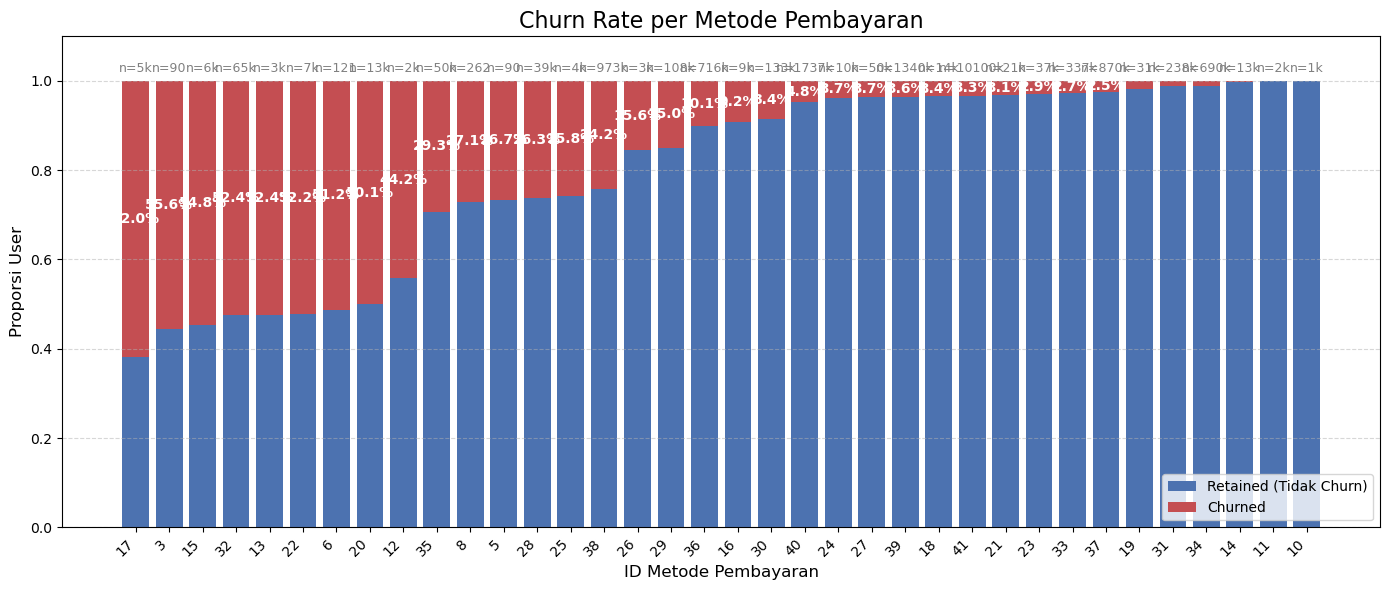

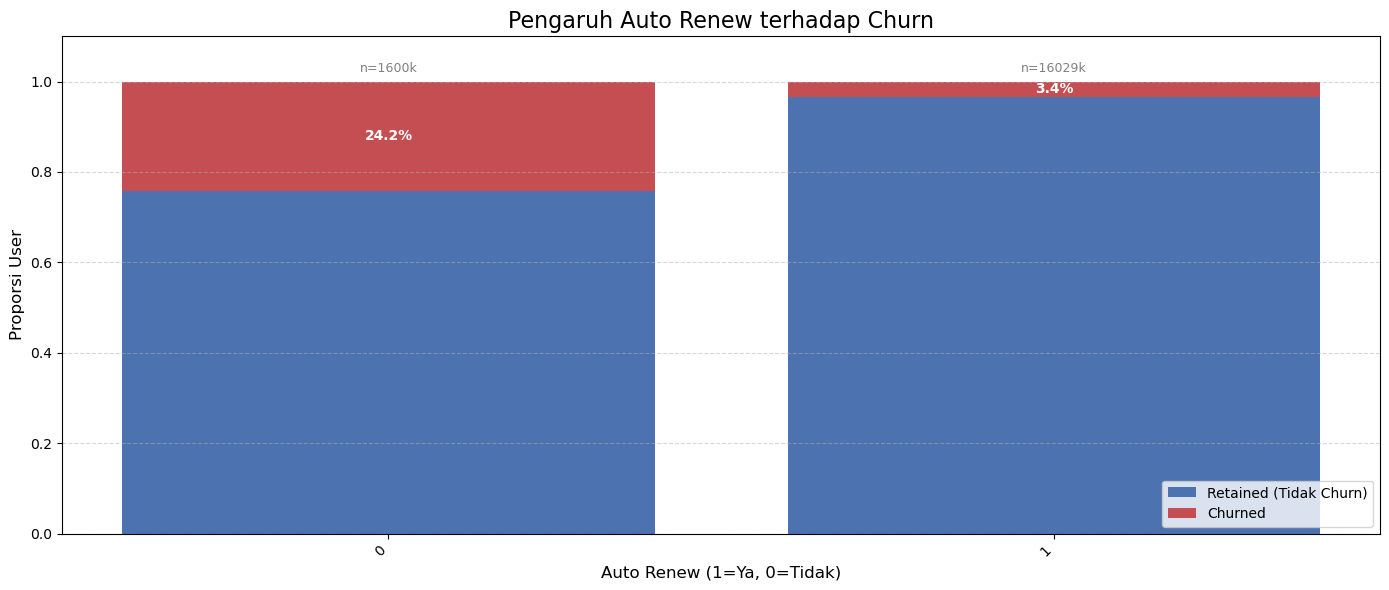

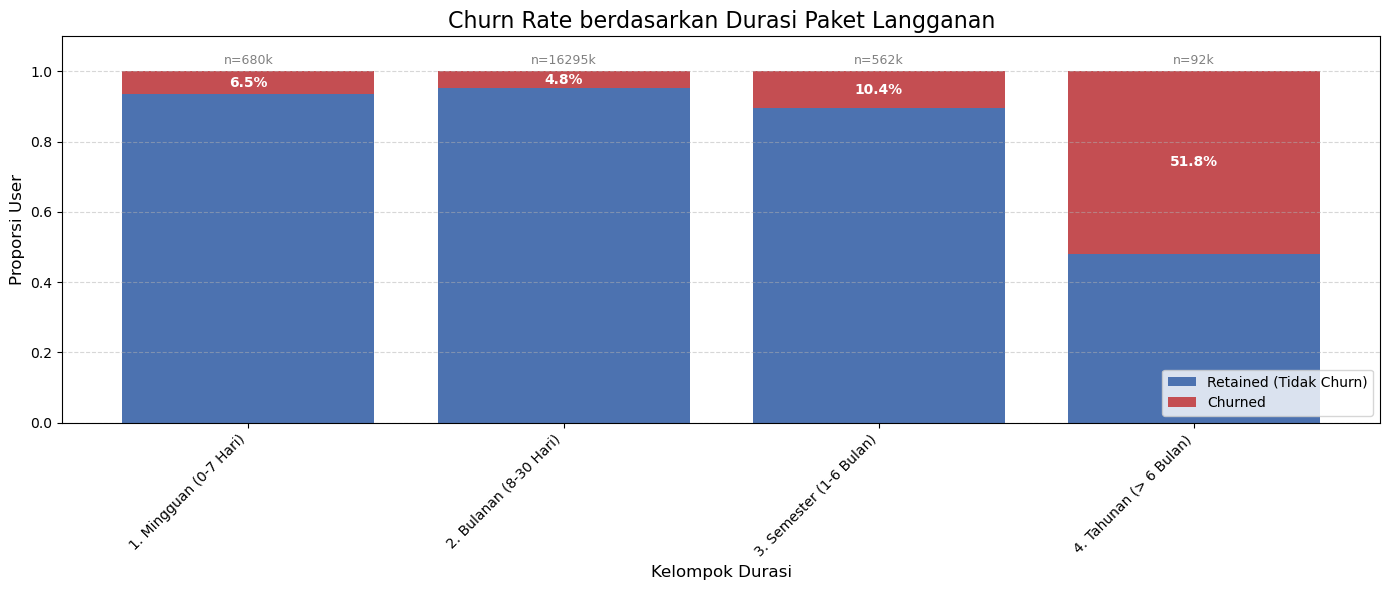

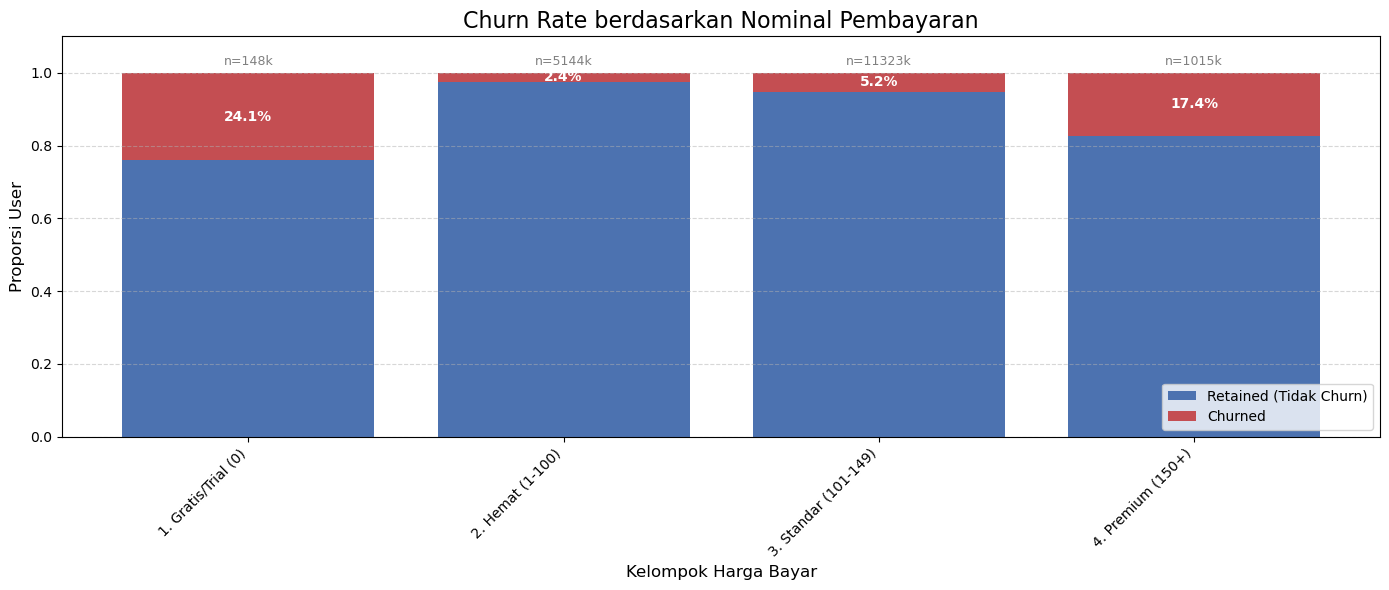

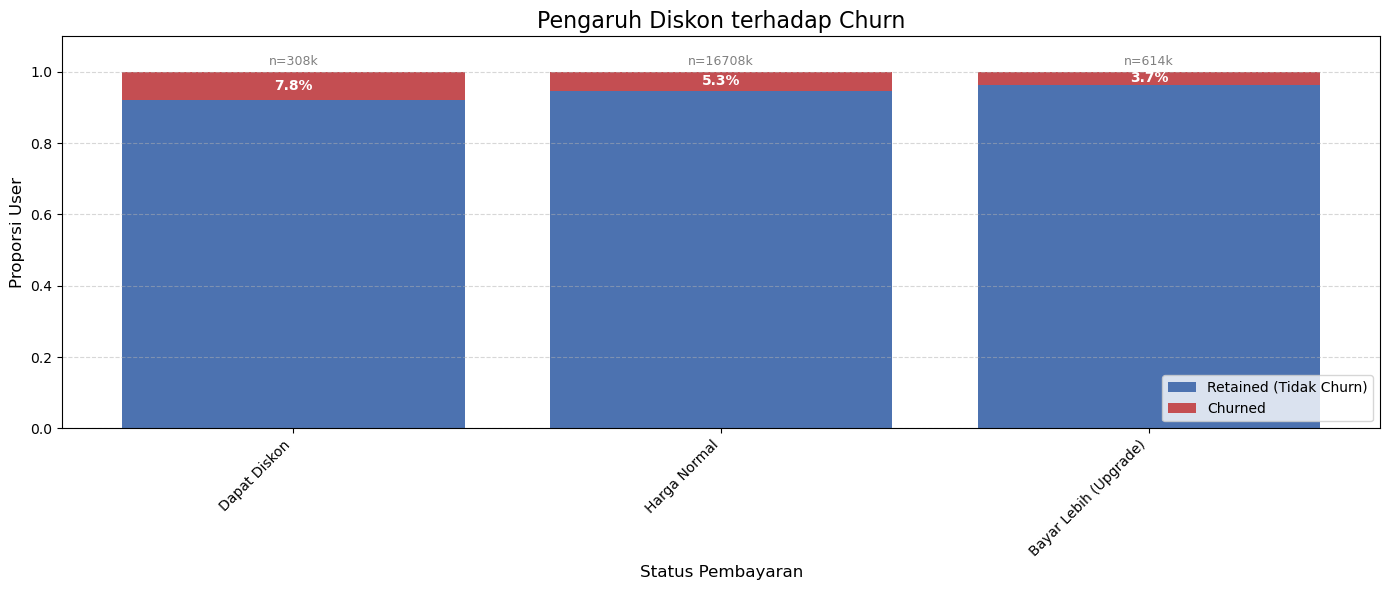

In [ ]:
# Filter data transaksi yang valid (memiliki label churn)
plot_data_trans = transactions_df.filter(F.col("is_churn").isNotNull())

print("--- Analisis Transaksi & Pembayaran ---")

# --- BINNING DATA NUMERIK ---
plot_data_binned = plot_data_trans.withColumn(
    "plan_days_group",
    F.when(F.col("payment_plan_days") <= 7, "1. Mingguan (0-7 Hari)")
     .when((F.col("payment_plan_days") > 7) & (F.col("payment_plan_days") <= 30), "2. Bulanan (8-30 Hari)")
     .when((F.col("payment_plan_days") > 30) & (F.col("payment_plan_days") <= 180), "3. Semester (1-6 Bulan)")
     .otherwise("4. Tahunan (> 6 Bulan)")
).withColumn(
    "amount_paid_group",
    F.when(F.col("actual_amount_paid") == 0, "1. Gratis/Trial (0)")
     .when((F.col("actual_amount_paid") > 0) & (F.col("actual_amount_paid") <= 100), "2. Hemat (1-100)")
     .when((F.col("actual_amount_paid") > 100) & (F.col("actual_amount_paid") <= 149), "3. Standar (101-149)")
     .otherwise("4. Premium (150+)")
).withColumn(
    "discount_status",
    F.when(F.col("actual_amount_paid") < F.col("plan_list_price"), "Dapat Diskon")
     .when(F.col("actual_amount_paid") == F.col("plan_list_price"), "Harga Normal")
     .when(F.col("actual_amount_paid") > F.col("plan_list_price"), "Bayar Lebih (Upgrade)")
     .otherwise("Lainnya")
)

# --- VISUALISASI ---

# 1. Payment Method
plot_churn_by_category(
    plot_data_binned, 
    "payment_method_id", 
    "Churn Rate per Metode Pembayaran", 
    sort_by_risk=True, 
    x_label="ID Metode Pembayaran"
)

# 2. Auto Renew
plot_churn_by_category(
    plot_data_binned, 
    "is_auto_renew", 
    "Pengaruh Auto Renew terhadap Churn", 
    sort_by_risk=True, 
    x_label="Auto Renew (1=Ya, 0=Tidak)"
)

# 3. Durasi Paket (Plan Days Group)
# Sort by False agar urut sesuai nama group (1. Mingguan -> 2. Bulanan -> dst)
plot_churn_by_category(
    plot_data_binned, 
    "plan_days_group", 
    "Churn Rate berdasarkan Durasi Paket Langganan", 
    sort_by_risk=False, 
    x_label="Kelompok Durasi"
)

# 4. Harga Bayar (Amount Paid Group)
plot_churn_by_category(
    plot_data_binned, 
    "amount_paid_group", 
    "Churn Rate berdasarkan Nominal Pembayaran", 
    sort_by_risk=False, 
    x_label="Kelompok Harga Bayar"
)

# 5. Status Diskon
plot_churn_by_category(
    plot_data_binned, 
    "discount_status", 
    "Pengaruh Diskon terhadap Churn", 
    sort_by_risk=True, 
    x_label="Status Pembayaran"
)